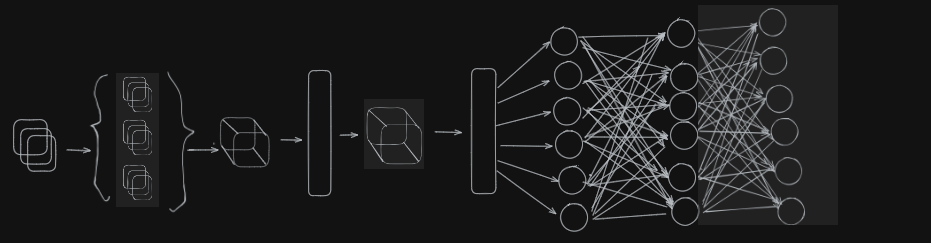

In [ ]:
import sys
import tensorflow as tf

print("Python:", sys.executable)
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

### Image Net
1) LeNet
2) AlexNet
3) Google Net
4) VaggNET
5) Resnet
6) Inception

## Artitecture of LeNet

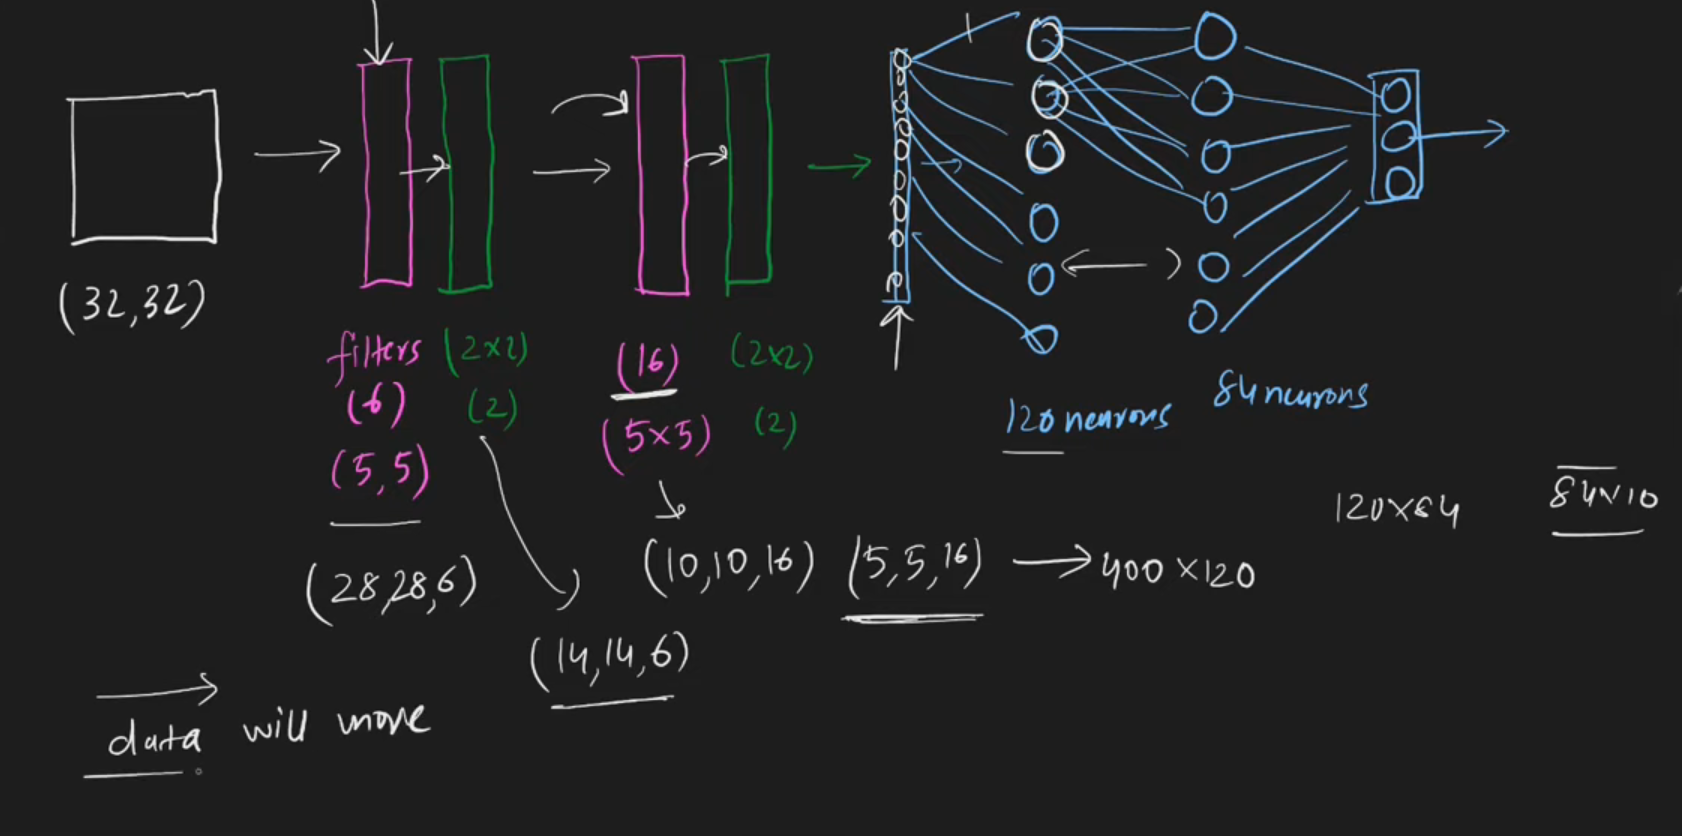

In [6]:
import tensorflow
from keras.layers import Dense,Conv2D,AveragePooling2D,Flatten
from keras.datasets import mnist

In [7]:
model= tf.keras.Sequential()
model.add(Conv2D(6, kernel_size=(5, 5), padding='valid',
                      activation='tanh', input_shape=(28, 28, 1)))
model.add(AveragePooling2D(pool_size=(2, 2), strides=2, padding='valid'))
model.add(Conv2D(16, kernel_size=(5, 5), padding='valid', activation='tanh'))
model.add(AveragePooling2D(pool_size=(2, 2), strides=2, padding='valid'))
model.add(Flatten())
model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))
model.add(Dense(10, activation='softmax'))

/mnt/d/NewVolume/DL-Algorithm/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
(X_train,y_train),(X_test,y_test) = mnist.load_data()

In [9]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
(X_train,y_train),(X_test,y_test) = mnist.load_data()

In [11]:
! nvidia-smi

Tue Aug 25 02:08:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.57.01              KMD Version: 610.88        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5050 ...    On  |   00000000:01:00.0 Off |                  N/A |
| N/A   45C    P8              3W /  100W |    5358MiB /   8151MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(X_train,y_train,epochs=10,validation_split=0.25)

Epoch 1/100


I0000 00:00:1787603950.499818   12237 service.cc:153] XLA service 0x706d10006e30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787603950.499853   12237 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5050 Laptop GPU, Compute Capability 12.0a (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1787603950.579016   12237 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787603950.816889   12237 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1787603950.854724   12237 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1901__.23


  62/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7485 - loss: 0.9070 

I0000 00:00:1787603961.729814   12237 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1395/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9500 - loss: 0.1687

I0000 00:00:1787603965.010533   12239 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1901__.23
I0000 00:00:1787603967.460987   12841 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_20', 20 bytes spill stores, 32 bytes spill loads

I0000 00:00:1787603967.461436   12831 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_20', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1787603967.462942   12840 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_20', 8 bytes spill stores, 48 bytes spill loads

I0000 00:00:1787603970.001099   12827 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 20 bytes spill stores, 32 bytes spill loads

I0000 00:00:1787603970.002075   12842 subprocess_compilati

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - accuracy: 0.9504 - loss: 0.1677 - val_accuracy: 0.9757 - val_loss: 0.0851
Epoch 2/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9775 - loss: 0.0730 - val_accuracy: 0.9756 - val_loss: 0.0807
Epoch 3/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9822 - loss: 0.0562 - val_accuracy: 0.9826 - val_loss: 0.0600
Epoch 4/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9867 - loss: 0.0430 - val_accuracy: 0.9790 - val_loss: 0.0678
Epoch 5/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9881 - loss: 0.0368 - val_accuracy: 0.9793 - val_loss: 0.0684
Epoch 6/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9902 - loss: 0.0296 - val_accuracy: 0.9804 - val_loss: 0.0654
Epoch 7/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9920 - loss: 0.0259 - val_accuracy: 0.9851 - val_loss: 0.0528
Epoch 8/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9930 - loss: 0.0221 - va